# Interactive RPS Predictor Evaluation

This notebook allows you to:
1. Sync models and results from vast-server
2. Select samples and listen to audio
3. View spectrograms
4. Evaluate specific models
5. Visualize results

## Step 1: Sync from Vast-Server

In [1]:
# Sync results and models from vast-server
# import subprocess
# import os

# def sync_from_vast():
#     """Sync models and results from vast-server."""
#     commands = [
#         # Sync RPS predictor results
#         "rsync -avz vast-server:/root/harmonic-noise-suppression/results/rps_eval_specific_samples/ ../results/rps_eval_specific_samples/",
#         "rsync -avz vast-server:/root/harmonic-noise-suppression/results/rps_train_specific_samples/ ../results/rps_train_specific_samples/",
#         # Sync models
#         "rsync -avz vast-server:/root/harmonic-noise-suppression/results/rps_predictor/best.pt ../results/rps_predictor/best.pt",
#         "rsync -avz vast-server:/root/harmonic-noise-suppression/results/rps_predictor_dcunet/best_dcunet_enc_rps.pt ../results/rps_predictor_dcunet/best_dcunet_enc_rps.pt",
#         "rsync -avz vast-server:/root/harmonic-noise-suppression/results/rps_predictor_dccrn_2/best_dccrn_enc_rps.pt ../results/rps_predictor_dccrn/best_dccrn_enc_rps.pt",
#     ]

#     for cmd in commands:
#         print(f"Running: {cmd}")
#         result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
#         if result.returncode == 0:
#             print("✓ Success")
#         else:
#             print(f"✗ Error: {result.stderr}")
#         print()

# # Run sync
# sync_from_vast()

## Step 2: Imports and Setup

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn.functional as F
import torchaudio
import IPython.display as ipd
from ipywidgets import interact, Dropdown, FloatSlider, fixed

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

# Import models
from train_rps_predictor import SimpleConv, DCUNetEncRPS, DCCRNEncRPS


def resample_rps_to_length(rps_gt: np.ndarray, target_len: int) -> np.ndarray:
    """Interpolate motor RPS to an STFT-length time grid (same as DREGONRPSDataset in train_rps_predictor.py)."""
    x = torch.from_numpy(np.asarray(rps_gt, dtype=np.float32)).unsqueeze(0)
    x = F.interpolate(x, size=target_len, mode="linear", align_corners=False)
    return x.squeeze(0).numpy()


# Setup
SAMPLE_RATE = 16000
device = torch.device('cpu')  # Always use CPU for local evaluation
print(f"Using device: {device}")

# Available samples
SAMPLES = ["00000", "00149", "00299", "00449", "00599"]
print(f"Available samples: {SAMPLES}")

Using device: cpu
Available samples: ['00000', '00149', '00299', '00449', '00599']


## Step 3: Load Models

In [3]:
def load_model(model_path, model_type):
    """Load a trained RPS predictor model."""
    if model_type == "simple_conv":
        model = SimpleConv()
    elif model_type == "dcunet":
        model = DCUNetEncRPS()
    elif model_type == "dccrn":
        model = DCCRNEncRPS()
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

# Model paths
model_paths = {
    "simple_conv": "../results/rps_predictor/best.pt",
    "dcunet": "../results/rps_predictor_dcunet/best_dcunet_enc_rps.pt",
    "dccrn": "../results/rps_predictor_dccrn_2/best_dccrn_enc_rps.pt"
}

# Load all models
models = {}
for name, path in model_paths.items():
    if Path(path).exists():
        models[name] = load_model(path, name)
        print(f"✓ Loaded {name}")
    else:
        print(f"✗ {name} not found at {path}")

print(f"\nLoaded {len(models)} models")

✓ Loaded simple_conv
✓ Loaded dcunet
✓ Loaded dccrn

Loaded 3 models


## Step 4: Sample Selection & Audio Playback

In [4]:
def load_sample_data(sample_id):
    """Load audio and RPS data for a sample."""
    sample_dir = Path(f"../results/rps_eval_specific_samples/sample_{sample_id}")
    # sample_dir = Path(f"../results/rps_train_specific_samples/sample_{sample_id}")

    if not sample_dir.exists():
        print(f"Sample {sample_id} not found. Sync from vast-server first.")
        return None

    # Load audio
    mixture, sr = torchaudio.load(sample_dir / "mixture.wav")

    # Load ground truth RPS
    rps_gt = np.load(sample_dir / "ground_truth_rps.npy")
    # rps_gt = np.load(sample_dir / "rps.npy")

    # Load predictions if available
    predictions = {}
    for model_name in ["simple_conv", "dcunet", "dccrn"]:
        pred_file = sample_dir / f"{model_name}_rps.npy"
        if pred_file.exists():
            predictions[model_name] = np.load(pred_file)

    return {
        "audio": mixture,
        "sr": sr,
        "rps_gt": rps_gt,
        "predictions": predictions,
        "sample_dir": sample_dir
    }

def play_sample(sample_id):
    """Play audio for a sample."""
    data = load_sample_data(sample_id)
    if data is None:
        return

    print(f"\n=== Sample {sample_id} ===")
    print(f"Duration: {data['audio'].shape[1] / data['sr']:.2f}s")
    print(f"RPS shape: {data['rps_gt'].shape}")
    print(f"Available predictions: {list(data['predictions'].keys())}")

    display(ipd.Audio(data["audio"].numpy(), rate=data["sr"]))

    return data

# Interactive sample selection
interact(play_sample, sample_id=Dropdown(options=SAMPLES, value=SAMPLES[0], description="Sample:"))

interactive(children=(Dropdown(description='Sample:', options=('00000', '00149', '00299', '00449', '00599'), v…

<function __main__.play_sample(sample_id)>

## Step 5: Spectrogram Visualization

In [5]:
def plot_spectrogram(sample_id, fmax=4000):
    """Plot spectrogram for a sample."""
    data = load_sample_data(sample_id)
    if data is None:
        return

    mixture = data["audio"].squeeze().numpy()
    sr = data["sr"]

    # Compute spectrogram
    n_fft = 2048
    hop_length = 512
    window = torch.hann_window(n_fft)
    X = torch.stft(torch.from_numpy(mixture).float(), n_fft=n_fft, hop_length=hop_length,
                   window=window, return_complex=True, normalized=True)
    Sxx = torch.abs(X).numpy()

    # Create time and frequency axes
    duration = len(mixture) / sr
    times = np.linspace(0, duration, Sxx.shape[1])
    freqs = np.linspace(0, sr/2, Sxx.shape[0])

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.pcolormesh(times, freqs, 20 * np.log10(Sxx + 1e-8),
                       shading='auto', cmap='magma')
    ax.set_ylabel('Frequency (Hz)', fontsize=12)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_title(f'Sample {sample_id} — Spectrogram', fontsize=14, fontweight='bold')
    ax.set_ylim(0, fmax)
    plt.colorbar(im, ax=ax, label='Magnitude (dB)')
    plt.tight_layout()
    plt.show()

# Interactive spectrogram
interact(
    plot_spectrogram,
    sample_id=Dropdown(options=SAMPLES, value=SAMPLES[0], description="Sample:"),
    fmax=FloatSlider(min=1000, max=8000, step=500, value=4000, description="Max Freq (Hz):")
)

interactive(children=(Dropdown(description='Sample:', options=('00000', '00149', '00299', '00449', '00599'), v…

<function __main__.plot_spectrogram(sample_id, fmax=4000)>

## Step 6: Model Evaluation

In [11]:
def evaluate_model(sample_id, model_name):
    """Evaluate a specific model on a sample."""
    # Load sample
    # sample_dir = Path(f"../results/rps_eval_specific_samples/sample_{sample_id}")
    sample_dir = Path(f"../results/rps_train_specific_samples/sample_{sample_id}")
    mixture, sr = torchaudio.load(sample_dir / "mixture.wav")
    # rps_gt = np.load(sample_dir / "ground_truth_rps.npy")
    rps_gt = np.load(sample_dir / "rps.npy")

    # Load model if not already loaded
    if model_name not in models:
        print(f"Model {model_name} not available. Please sync models first.")
        return None

    model = models[model_name]

    # Predict
    with torch.no_grad():
        pred = model(mixture.squeeze(0).to(device))
        pred_np = pred.squeeze(0).cpu().numpy()

    # Match lengths: interpolate raw motor RPS to prediction time resolution (STFT frames)
    target_len = pred_np.shape[1]
    rps_gt = resample_rps_to_length(rps_gt, target_len)

    # Compute metrics
    mse = np.mean((pred_np - rps_gt) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(pred_np - rps_gt))

    ss_res = np.sum((rps_gt - pred_np) ** 2)
    ss_tot = np.sum((rps_gt - rps_gt.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

    # Per-rotor metrics
    per_rotor_mae = [np.mean(np.abs(pred_np[i] - rps_gt[i])) for i in range(4)]

    results = {
        "mixture": mixture.squeeze(0).to(device),
        "sample_id": sample_id,
        "model_name": model_name,
        "prediction": pred_np,
        "ground_truth": rps_gt,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "per_rotor_mae": per_rotor_mae
        }
    }

    print(f"\n=== Evaluation Results ===")
    print(f"Sample: {sample_id}")
    print(f"Model: {model_name}")
    print(f"\nMetrics:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"\nPer-Rotor MAE:")
    for i, mae in enumerate(per_rotor_mae):
        print(f"  Rotor {i+1}: {mae:.4f}")

    return results

# Interactive evaluation
eval_result = interact(
    evaluate_model,
    sample_id=Dropdown(options=SAMPLES, value=SAMPLES[0], description="Sample:"),
    model_name=Dropdown(options=["simple_conv", "dcunet", "dccrn"], value="dccrn", description="Model:")
)

interactive(children=(Dropdown(description='Sample:', options=('00000', '00149', '00299', '00449', '00599'), v…

## Step 7: Visualization of Results

Run the cell below after evaluating a model to visualize the results.

In [12]:
# Store the last evaluation result in a variable for plotting
# After running the evaluation cell above, run this cell to capture the result
try:
    last_result = eval_result.widget.result
    print(f"Captured result for {last_result['model_name']} on {last_result['sample_id']}")
except:
    print("No result captured yet. Run the evaluation cell above first.")
    last_result = None

Captured result for dccrn on 00000


(4, 258)
(4, 258)


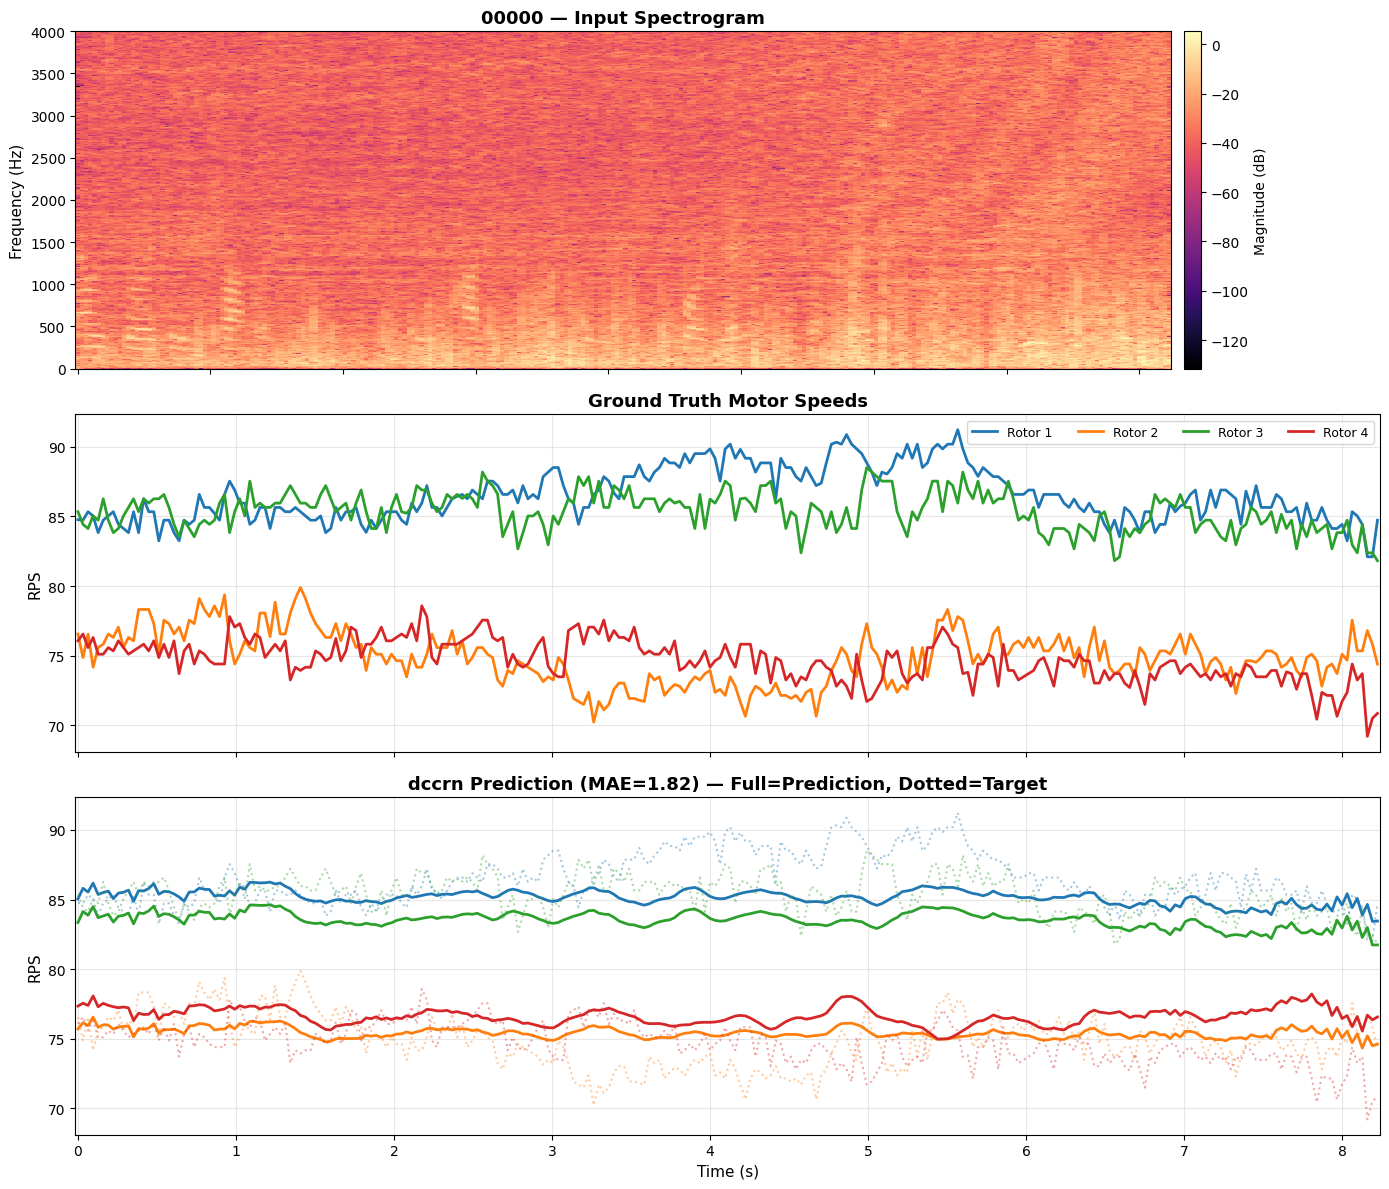

In [13]:
def plot_evaluation_result(result, show_spectrogram=True):
    """Plot evaluation results."""
    if result is None:
        print("No result to plot. Run evaluation first.")
        return

    mixture = result["mixture"]
    pred = result["prediction"]
    gt = result["ground_truth"]
    sample_id = result["sample_id"]
    model_name = result["model_name"]
    mae = result["metrics"]["mae"]

    print(pred.shape)
    print(gt.shape)

    display(ipd.Audio(mixture.numpy(), rate=16000))

    # Time axis (match mixture length)
    duration = float(mixture.shape[-1]) / SAMPLE_RATE
    t = np.linspace(0, duration, pred.shape[1])

    rotor_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Create figure
    if show_spectrogram:
        fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

        # Spectrogram (same waveform as evaluation)
        ax_spec = axes[0]
        mixture_np = mixture.numpy()
        sr = SAMPLE_RATE

        n_fft = 2048
        hop_length = 512
        window = torch.hann_window(n_fft)
        X = torch.stft(torch.from_numpy(mixture_np).float(), n_fft=n_fft, hop_length=hop_length,
                       window=window, return_complex=True, normalized=True)
        Sxx = torch.abs(X).numpy()

        spec_times = np.linspace(0, duration, Sxx.shape[1])
        freqs = np.linspace(0, sr/2, Sxx.shape[0])

        im = ax_spec.pcolormesh(spec_times, freqs, 20 * np.log10(Sxx + 1e-8),
                                shading='auto', cmap='magma')
        ax_spec.set_ylabel('Frequency (Hz)', fontsize=11)
        ax_spec.set_title(f'{sample_id} — Input Spectrogram', fontsize=13, fontweight='bold')
        ax_spec.set_ylim(0, 4000)
        plt.colorbar(im, ax=ax_spec, label='Magnitude (dB)', pad=0.01)

        # GT plot
        ax_gt = axes[1]
        for i, color in enumerate(rotor_colors):
            ax_gt.plot(t, gt[i], label=f'Rotor {i+1}', color=color, linewidth=2)
        ax_gt.set_ylabel('RPS', fontsize=11)
        ax_gt.set_title('Ground Truth Motor Speeds', fontsize=13, fontweight='bold')
        ax_gt.legend(loc='upper right', ncol=4, fontsize=9)
        ax_gt.grid(True, alpha=0.3)

        # Prediction plot
        ax_pred = axes[2]
        for i, color in enumerate(rotor_colors):
            ax_pred.plot(t, gt[i], color=color, linewidth=1.5, linestyle=':', alpha=0.4)
            ax_pred.plot(t, pred[i], color=color, linewidth=2, label=f'Rotor {i+1}' if i == 0 else "")
        ax_pred.set_ylabel('RPS', fontsize=11)
        ax_pred.set_xlabel('Time (s)', fontsize=11)
        ax_pred.set_title(f'{model_name} Prediction (MAE={mae:.2f}) — Full=Prediction, Dotted=Target',
                     fontsize=13, fontweight='bold')
        ax_pred.grid(True, alpha=0.3)
    else:
        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        # GT plot
        ax_gt = axes[0]
        for i, color in enumerate(rotor_colors):
            ax_gt.plot(t, gt[i], label=f'Rotor {i+1}', color=color, linewidth=2)
        ax_gt.set_ylabel('RPS', fontsize=11)
        ax_gt.set_title('Ground Truth Motor Speeds', fontsize=13, fontweight='bold')
        ax_gt.legend(loc='upper right', ncol=4, fontsize=9)
        ax_gt.grid(True, alpha=0.3)

        # Prediction plot
        ax_pred = axes[1]
        for i, color in enumerate(rotor_colors):
            ax_pred.plot(t, gt[i], color=color, linewidth=1.5, linestyle=':', alpha=0.4)
            ax_pred.plot(t, pred[i], color=color, linewidth=2, label=f'Rotor {i+1}' if i == 0 else "")
        ax_pred.set_ylabel('RPS', fontsize=11)
        ax_pred.set_xlabel('Time (s)', fontsize=11)
        ax_pred.set_title(f'{model_name} Prediction (MAE={mae:.2f}) — Full=Prediction, Dotted=Target',
                     fontsize=13, fontweight='bold')
        ax_pred.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot the last result
plot_evaluation_result(last_result, show_spectrogram=True)

## Step 8: Compare All Models on a Sample

In [14]:
def compare_all_models(sample_id):
    """Compare all models on a single sample."""
    # Load data
    data = load_sample_data(sample_id)
    if data is None:
        return

    gt_raw = data["rps_gt"]
    mixture_np = data["audio"].squeeze().numpy()
    sr = data["sr"]
    duration = mixture_np.shape[0] / sr
    n_fft, hop_length = 2048, 512
    n_frames_stft = mixture_np.shape[0] // hop_length + 1
    gt_stft = resample_rps_to_length(gt_raw, n_frames_stft)
    t_stft = np.linspace(0, duration, n_frames_stft)

    rotor_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Create figure with 5 subplots
    fig = plt.figure(figsize=(16, 16))
    gs = fig.add_gridspec(5, 1, height_ratios=[1.2, 1, 1, 1, 1], hspace=0.3)

    # Spectrogram
    ax_spec = fig.add_subplot(gs[0])
    window = torch.hann_window(n_fft)
    X = torch.stft(torch.from_numpy(mixture_np).float(), n_fft=n_fft, hop_length=hop_length,
                   window=window, return_complex=True, normalized=True)
    Sxx = torch.abs(X).numpy()

    spec_times = np.linspace(0, duration, Sxx.shape[1])
    freqs = np.linspace(0, data["sr"]/2, Sxx.shape[0])

    im = ax_spec.pcolormesh(spec_times, freqs, 20 * np.log10(Sxx + 1e-8),
                            shading='auto', cmap='magma')
    ax_spec.set_ylabel('Frequency (Hz)', fontsize=11)
    ax_spec.set_title(f'{sample_id} — Input Spectrogram', fontsize=13, fontweight='bold')
    ax_spec.set_ylim(0, 4000)
    plt.colorbar(im, ax=ax_spec, label='Magnitude (dB)', pad=0.01)

    # Ground Truth (interpolated to STFT frame count, same as training target grid)
    ax_gt = fig.add_subplot(gs[1], sharex=ax_spec)
    for i, color in enumerate(rotor_colors):
        ax_gt.plot(t_stft, gt_stft[i], label=f'Rotor {i+1}', color=color, linewidth=2)
    ax_gt.set_ylabel('RPS', fontsize=11)
    ax_gt.set_title('Ground Truth Motor Speeds', fontsize=13, fontweight='bold')
    ax_gt.legend(loc='upper right', ncol=4, fontsize=9)
    ax_gt.grid(True, alpha=0.3)

    # Model predictions
    model_names = ["simple_conv", "dcunet", "dccrn"]
    model_labels = ["SimpleConv", "DCUNet", "DCCRN"]

    for idx, (model_name, label) in enumerate(zip(model_names, model_labels)):
        ax = fig.add_subplot(gs[2 + idx], sharex=ax_spec)

        if model_name in data["predictions"]:
            pred = data["predictions"][model_name]
            gt_matched = resample_rps_to_length(gt_raw, pred.shape[1])
            t_pred = np.linspace(0, duration, pred.shape[1])

            for i, color in enumerate(rotor_colors):
                ax.plot(t_pred, gt_matched[i], color=color, linewidth=1.5, linestyle=':', alpha=0.4)
                ax.plot(t_pred, pred[i], color=color, linewidth=2)

            mae = np.mean(np.abs(pred - gt_matched))
            ax.set_title(f'{label} Prediction (MAE={mae:.2f})', fontsize=13, fontweight='bold')
        else:
            ax.set_title(f'{label} — Not Available', fontsize=13, fontweight='bold')

        ax.set_ylabel('RPS', fontsize=11)
        ax.grid(True, alpha=0.3)
        if idx == 2:
            ax.set_xlabel('Time (s)', fontsize=11)

    plt.tight_layout()
    plt.show()

# Interactive comparison
interact(compare_all_models, sample_id=Dropdown(options=SAMPLES, value=SAMPLES[0], description="Sample:"))

interactive(children=(Dropdown(description='Sample:', options=('00000', '00149', '00299', '00449', '00599'), v…

<function __main__.compare_all_models(sample_id)>

## Step 9: Access Raw Data

You can access the raw data programmatically in cells below:

In [17]:
# Example: Get predictions for sample_00000
sample_id = "00000"
data = load_sample_data(sample_id)

if data:
    print(f"Sample {sample_id} data:")
    print(f"  Audio shape: {data['audio'].shape}")
    print(f"  GT RPS shape: {data['rps_gt'].shape}")
    print(f"  Predictions available: {list(data['predictions'].keys())}")

    # Example: Compute custom metric
    if 'dccrn' in data['predictions']:
        pred = data['predictions']['simple_conv']
        gt = resample_rps_to_length(data['rps_gt'], pred.shape[1])

        # Max absolute error
        max_err = np.max(np.abs(pred - gt))
        print(f"\n  DCCRN Max Error: {max_err:.4f}")

        # Per-rotor correlation
        for i in range(4):
            corr = np.corrcoef(pred[i], gt[i])[0, 1]
            print(f"  Rotor {i+1} correlation: {corr:.4f}")

Sample 00000 data:
  Audio shape: torch.Size([1, 131584])
  GT RPS shape: (4, 7814)
  Predictions available: ['simple_conv', 'dcunet', 'dccrn']

  DCCRN Max Error: 5.3289
  Rotor 1 correlation: 0.7582
  Rotor 2 correlation: 0.4830
  Rotor 3 correlation: 0.3673
  Rotor 4 correlation: 0.6777
